# Notebook 10 — ECGRiskNet-XAI · Complete Model Strength Report

Reads all JSON artifacts saved by NB1–NB9 and prints a clean unified dashboard:

| Source | JSON file |
|--------|-----------|
| NB4 Training (PTB-XL) | `training_results.json` |
| NB6b Train/Val/Test re-eval | `train_eval_results.json` |
| NB6c Joint model (PTB-XL + INCART) | `joint_training_results.json` |
| NB6 / NB6d Cross-dataset OOD | `crossdataset_results.json` |
| NB7 Edge AI compression | `edge_metrics.json` |

**No re-training. No re-inference. Pure read + display.**

In [1]:
import json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings("ignore")

SAVE_DIR = Path("./ECG_Project/data")
FIGS_DIR = SAVE_DIR / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RISK_LABELS = {0: "Low", 1: "Moderate", 2: "High", 3: "Critical"}
COLORS = {"Low": "#2ecc71", "Moderate": "#3498db", "High": "#e67e22", "Critical": "#e74c3c"}

def safe_load(path, label=""):
    p = Path(path)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    print(f"  ⚠️  {label or p.name} not found — skipping")
    return {}

def g(d, *keys, default=None):
    for k in keys:
        if not isinstance(d, dict): return default
        d = d.get(k, default)
        if d is None: return default
    return d

def pct(v):  return f"{v*100:.2f}%" if v is not None else "—"
def f4(v):   return f"{v:.4f}"      if v is not None else "—"
def f2(v):   return f"{v:.2f}"      if v is not None else "—"

# Load all JSONs
tr = safe_load(SAVE_DIR / "training_results.json",       "NB4  training_results")
ev = safe_load(SAVE_DIR / "train_eval_results.json",     "NB6b train_eval_results")
jr = safe_load(SAVE_DIR / "joint_training_results.json", "NB6c joint_training_results")
cr = safe_load(SAVE_DIR / "crossdataset_results.json",   "NB6/6d crossdataset_results")
em = safe_load(SAVE_DIR / "edge_metrics.json",           "NB7  edge_metrics")

print("✅ JSONs loaded.")
print(f"   training_results   keys: {list(tr.keys())[:8]}")
print(f"   train_eval_results keys: {list(ev.keys())[:8]}")
print(f"   joint_training     keys: {list(jr.keys())[:8]}")
print(f"   crossdataset       keys: {list(cr.keys())[:8]}")
print(f"   edge_metrics       keys: {list(em.keys())[:8]}")


  ⚠️  NB4  training_results not found — skipping
  ⚠️  NB6b train_eval_results not found — skipping
  ⚠️  NB6c joint_training_results not found — skipping
  ⚠️  NB6/6d crossdataset_results not found — skipping
  ⚠️  NB7  edge_metrics not found — skipping
✅ JSONs loaded.
   training_results   keys: []
   train_eval_results keys: []
   joint_training     keys: []
   crossdataset       keys: []
   edge_metrics       keys: []


In [2]:
print()
print("╔══════════════════════════════════════════════════════════════════════════════════╗")
print("║   SECTION 1 — PTB-XL Performance (Single-Dataset Model, NB4)                  ║")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")

# NB4 saves: best_val_f1, test_accuracy, test_macro_f1, test_weighted_f1, test_roc_auc,
#            test_mcc, test_kappa, test_pr_auc, best_epoch, history{train_acc...}
# NB6b saves: ptbxl_train{accuracy,macro_f1,weighted_f1,mcc,kappa,roc_auc}
#             ptbxl_val  {same}   ptbxl_test {same}

train_acc = g(ev, "ptbxl_train", "accuracy")
train_f1  = g(ev, "ptbxl_train", "macro_f1")
train_wf1 = g(ev, "ptbxl_train", "weighted_f1")
train_mcc = g(ev, "ptbxl_train", "mcc")
train_kap = g(ev, "ptbxl_train", "kappa")
train_roc = g(ev, "ptbxl_train", "roc_auc")

val_acc   = g(ev, "ptbxl_val", "accuracy")
val_f1    = g(ev, "ptbxl_val", "macro_f1")
val_wf1   = g(ev, "ptbxl_val", "weighted_f1")
val_mcc   = g(ev, "ptbxl_val", "mcc")
val_kap   = g(ev, "ptbxl_val", "kappa")
val_roc   = g(ev, "ptbxl_val", "roc_auc")

# NB4 test is the authoritative source for test metrics
test_acc  = g(tr, "test_accuracy")
test_f1   = g(tr, "test_macro_f1")
test_wf1  = g(tr, "test_weighted_f1")
test_mcc  = g(tr, "test_mcc")
test_kap  = g(tr, "test_kappa")
test_roc  = g(tr, "test_roc_auc")
test_pr   = g(tr, "test_pr_auc")

best_ep   = g(tr, "best_epoch")
best_vf1  = g(tr, "best_val_f1")

H = f"  {'Split':<22} {'Accuracy':>10} {'Macro F1':>10} {'Wtd F1':>10} {'ROC-AUC':>10} {'MCC':>8} {'Kappa':>8}"
SEP = "  " + "─" * 82
print(H); print(SEP)

def pr(label, acc, f1, wf1, roc, mcc, kap):
    print(f"  {label:<22} {pct(acc):>10} {f4(f1):>10} {f4(wf1):>10} {f4(roc):>10} {f4(mcc):>8} {f4(kap):>8}")

pr("Train  (NB6b)",  train_acc, train_f1, train_wf1, train_roc, train_mcc, train_kap)
pr("Val    (NB6b)",  val_acc,   val_f1,   val_wf1,   val_roc,   val_mcc,   val_kap)
pr("Test   (NB4) ★", test_acc,  test_f1,  test_wf1,  test_roc,  test_mcc,  test_kap)
print(SEP)
print(f"  Best Val Macro F1 = {f4(best_vf1)}  at epoch {best_ep or '—'}")
if test_pr: print(f"  Test PR-AUC       = {f4(test_pr)}")
print()
print("  ★ = primary held-out test result")



╔══════════════════════════════════════════════════════════════════════════════════╗
║   SECTION 1 — PTB-XL Performance (Single-Dataset Model, NB4)                  ║
╚══════════════════════════════════════════════════════════════════════════════════╝
  Split                    Accuracy   Macro F1     Wtd F1    ROC-AUC      MCC    Kappa
  ──────────────────────────────────────────────────────────────────────────────────
  Train  (NB6b)                   —          —          —          —        —        —
  Val    (NB6b)                   —          —          —          —        —        —
  Test   (NB4) ★                  —          —          —          —        —        —
  ──────────────────────────────────────────────────────────────────────────────────
  Best Val Macro F1 = —  at epoch —

  ★ = primary held-out test result


In [3]:
print()
print("╔══════════════════════════════════════════════════════════════════════════════════╗")
print("║   SECTION 2 — Joint Model: PTB-XL + INCART (NB6c)                             ║")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")
print("  Model trained on PTB-XL-train + INCART-train, evaluated on held-out val splits.")
print()

# NB6c saves: ptbxl_val{}, incart_val{}, pooled_val{}
jptb_acc  = g(jr, "ptbxl_val", "accuracy");  jptb_f1  = g(jr, "ptbxl_val", "macro_f1")
jptb_wf1  = g(jr, "ptbxl_val", "weighted_f1"); jptb_roc = g(jr, "ptbxl_val", "roc_auc")
jptb_mcc  = g(jr, "ptbxl_val", "mcc");       jptb_kap = g(jr, "ptbxl_val", "kappa")

jinc_acc  = g(jr, "incart_val", "accuracy"); jinc_f1  = g(jr, "incart_val", "macro_f1")
jinc_wf1  = g(jr, "incart_val", "weighted_f1"); jinc_roc = g(jr, "incart_val", "roc_auc")
jinc_mcc  = g(jr, "incart_val", "mcc");     jinc_kap = g(jr, "incart_val", "kappa")

jpoo_acc  = g(jr, "pooled_val", "accuracy"); jpoo_f1  = g(jr, "pooled_val", "macro_f1")
jpoo_wf1  = g(jr, "pooled_val", "weighted_f1"); jpoo_roc = g(jr, "pooled_val", "roc_auc")
jpoo_mcc  = g(jr, "pooled_val", "mcc");     jpoo_kap = g(jr, "pooled_val", "kappa")

best_j    = g(jr, "best_val_macro_f1")
best_j_ep = g(jr, "best_epoch")

H = f"  {'Val Split':<22} {'Accuracy':>10} {'Macro F1':>10} {'Wtd F1':>10} {'ROC-AUC':>10} {'MCC':>8} {'Kappa':>8}"
print(H); print(SEP)
pr("PTB-XL Val",  jptb_acc, jptb_f1, jptb_wf1, jptb_roc, jptb_mcc, jptb_kap)
pr("INCART Val",  jinc_acc, jinc_f1, jinc_wf1, jinc_roc, jinc_mcc, jinc_kap)
pr("Pooled Val ★",jpoo_acc, jpoo_f1, jpoo_wf1, jpoo_roc, jpoo_mcc, jpoo_kap)
print(SEP)
print(f"  Best Joint Val Macro F1 = {f4(best_j)}  at epoch {best_j_ep or '—'}")
print()
print("  ★ = combined PTB-XL + INCART val pool")



╔══════════════════════════════════════════════════════════════════════════════════╗
║   SECTION 2 — Joint Model: PTB-XL + INCART (NB6c)                             ║
╚══════════════════════════════════════════════════════════════════════════════════╝
  Model trained on PTB-XL-train + INCART-train, evaluated on held-out val splits.

  Val Split                Accuracy   Macro F1     Wtd F1    ROC-AUC      MCC    Kappa
  ──────────────────────────────────────────────────────────────────────────────────
  PTB-XL Val                      —          —          —          —        —        —
  INCART Val                      —          —          —          —        —        —
  Pooled Val ★                    —          —          —          —        —        —
  ──────────────────────────────────────────────────────────────────────────────────
  Best Joint Val Macro F1 = —  at epoch —

  ★ = combined PTB-XL + INCART val pool


In [4]:
print()
print("╔══════════════════════════════════════════════════════════════════════════════════╗")
print("║   SECTION 3 — Cross-Dataset / Out-of-Distribution Generalization               ║")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")
print("  All datasets below were NEVER seen during training.")
print()

# NB6  saves: incart_accuracy, incart_macro_f1, incart_weighted_f1, incart_roc_auc, incart_mcc, incart_kappa
# NB6d saves: cpsc2018_*, chapman_*

rows_ood = [
    ("INCART    (NB6)",
     g(cr,"incart_accuracy"),   g(cr,"incart_macro_f1"),
     g(cr,"incart_weighted_f1"),g(cr,"incart_roc_auc"),
     g(cr,"incart_mcc"),        g(cr,"incart_kappa"),
     g(cr,"incart_n_segments")),
    ("CPSC-2018 (NB6d)",
     g(cr,"cpsc2018_accuracy"),   g(cr,"cpsc2018_macro_f1"),
     g(cr,"cpsc2018_weighted_f1"),g(cr,"cpsc2018_roc_auc"),
     g(cr,"cpsc2018_mcc"),        g(cr,"cpsc2018_kappa"),
     g(cr,"cpsc2018_n_segments")),
    ("Chapman   (NB6d)",
     g(cr,"chapman_accuracy"),   g(cr,"chapman_macro_f1"),
     g(cr,"chapman_weighted_f1"),g(cr,"chapman_roc_auc"),
     g(cr,"chapman_mcc"),        g(cr,"chapman_kappa"),
     g(cr,"chapman_n_segments")),
]

H2 = f"  {'Dataset':<22} {'Accuracy':>10} {'Macro F1':>10} {'Wtd F1':>10} {'ROC-AUC':>10} {'MCC':>8} {'Kappa':>8} {'Segments':>10}"
print(H2); print("  " + "─" * 94)
for label, acc, f1, wf1, roc, mcc, kap, n in rows_ood:
    n_str = f"{n:,}" if n else "—"
    print(f"  {label:<22} {pct(acc):>10} {f4(f1):>10} {f4(wf1):>10} {f4(roc):>10} {f4(mcc):>8} {f4(kap):>8} {n_str:>10}")
print("  " + "─" * 94)
print()

# Domain gap commentary
if g(cr,"incart_accuracy") and g(tr,"test_accuracy"):
    gap_incart = (g(tr,"test_accuracy") - g(cr,"incart_accuracy")) * 100
    print(f"  Domain gap vs PTB-XL test:")
    print(f"    INCART    accuracy drop : {gap_incart:+.2f} pp")
if g(cr,"cpsc2018_accuracy"):
    gap_cpsc = (g(tr,"test_accuracy") - g(cr,"cpsc2018_accuracy")) * 100
    print(f"    CPSC-2018 accuracy drop : {gap_cpsc:+.2f} pp")
if g(cr,"chapman_accuracy"):
    gap_chap = (g(tr,"test_accuracy") - g(cr,"chapman_accuracy")) * 100
    print(f"    Chapman   accuracy drop : {gap_chap:+.2f} pp")



╔══════════════════════════════════════════════════════════════════════════════════╗
║   SECTION 3 — Cross-Dataset / Out-of-Distribution Generalization               ║
╚══════════════════════════════════════════════════════════════════════════════════╝
  All datasets below were NEVER seen during training.

  Dataset                  Accuracy   Macro F1     Wtd F1    ROC-AUC      MCC    Kappa   Segments
  ──────────────────────────────────────────────────────────────────────────────────────────────
  INCART    (NB6)                 —          —          —          —        —        —          —
  CPSC-2018 (NB6d)                —          —          —          —        —        —          —
  Chapman   (NB6d)                —          —          —          —        —        —          —
  ──────────────────────────────────────────────────────────────────────────────────────────────



In [5]:
print()
print("╔══════════════════════════════════════════════════════════════════════════════════╗")
print("║   SECTION 4 — Edge AI Compression (NB7)                                       ║")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")
print("  All variants evaluated on PTB-XL test set.")
print()

# NB7 edge_metrics.json keys: "Original", "Quantized", "Pruned", "TorchScript"
# each has: accuracy, macro_f1, latency_ms, size_mb
variants = ["Original", "Quantized", "Pruned", "TorchScript"]

if em:
    base_acc = g(em, "Original", "accuracy") or 0
    base_f1  = g(em, "Original", "macro_f1") or 0
    H3 = f"  {'Variant':<14} {'Accuracy':>10} {'Macro F1':>10} {'Acc Drop':>10} {'F1 Drop':>10} {'Latency ms':>12} {'Size MB':>9}"
    print(H3); print("  " + "─" * 82)
    for v in variants:
        acc = g(em, v, "accuracy")
        f1  = g(em, v, "macro_f1")
        lat = g(em, v, "latency_ms")
        sz  = g(em, v, "size_mb")
        drop_a = f"{(base_acc-acc)*100:+.2f}pp" if acc is not None else "—"
        drop_f = f"{(base_f1-f1):+.4f}"         if f1  is not None else "—"
        lat_s  = f"{lat:.2f}"  if lat else "—"
        sz_s   = f"{sz:.2f}"   if sz  else "—"
        print(f"  {v:<14} {pct(acc):>10} {f4(f1):>10} {drop_a:>10} {drop_f:>10} {lat_s:>12} {sz_s:>9}")
    print("  " + "─" * 82)
    print("  Acc Drop / F1 Drop = relative to Original model")
else:
    print("  edge_metrics.json not found — run NB7 first")



╔══════════════════════════════════════════════════════════════════════════════════╗
║   SECTION 4 — Edge AI Compression (NB7)                                       ║
╚══════════════════════════════════════════════════════════════════════════════════╝
  All variants evaluated on PTB-XL test set.

  edge_metrics.json not found — run NB7 first


In [6]:
print()
print("╔══════════════════════════════════════════════════════════════════════════════════╗")
print("║   SECTION 5 — Master Comparison Table (All Datasets)                           ║")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")
print()

all_rows = [
    # label, model, acc, macro_f1, roc_auc
    ("PTB-XL Train",          "PTB-XL only",         g(ev,"ptbxl_train","accuracy"), g(ev,"ptbxl_train","macro_f1"), g(ev,"ptbxl_train","roc_auc")),
    ("PTB-XL Val",            "PTB-XL only",         g(ev,"ptbxl_val","accuracy"),   g(ev,"ptbxl_val","macro_f1"),   g(ev,"ptbxl_val","roc_auc")),
    ("PTB-XL Test ★",         "PTB-XL only",         g(tr,"test_accuracy"),          g(tr,"test_macro_f1"),          g(tr,"test_roc_auc")),
    ("Joint PTB-XL Val",      "PTB-XL+INCART",       g(jr,"ptbxl_val","accuracy"),   g(jr,"ptbxl_val","macro_f1"),   g(jr,"ptbxl_val","roc_auc")),
    ("Joint INCART Val",      "PTB-XL+INCART",       g(jr,"incart_val","accuracy"),  g(jr,"incart_val","macro_f1"),  g(jr,"incart_val","roc_auc")),
    ("Joint Pooled Val ★",    "PTB-XL+INCART",       g(jr,"pooled_val","accuracy"),  g(jr,"pooled_val","macro_f1"),  g(jr,"pooled_val","roc_auc")),
    ("INCART OOD ★",          "PTB-XL only",         g(cr,"incart_accuracy"),        g(cr,"incart_macro_f1"),        g(cr,"incart_roc_auc")),
    ("CPSC-2018 OOD ★",       "PTB-XL+INCART",       g(cr,"cpsc2018_accuracy"),      g(cr,"cpsc2018_macro_f1"),      g(cr,"cpsc2018_roc_auc")),
    ("Chapman OOD ★",         "PTB-XL+INCART",       g(cr,"chapman_accuracy"),       g(cr,"chapman_macro_f1"),       g(cr,"chapman_roc_auc")),
]

H4 = f"  {'Dataset':<24} {'Model':<18} {'Accuracy':>10} {'Macro F1':>10} {'ROC-AUC':>10}"
print(H4); print("  " + "═" * 74)
for label, model, acc, f1, roc in all_rows:
    print(f"  {label:<24} {model:<18} {pct(acc):>10} {f4(f1):>10} {f4(roc):>10}")
print("  " + "═" * 74)
print()
print("  ★ = primary evaluation result for each dataset")



╔══════════════════════════════════════════════════════════════════════════════════╗
║   SECTION 5 — Master Comparison Table (All Datasets)                           ║
╚══════════════════════════════════════════════════════════════════════════════════╝

  Dataset                  Model                Accuracy   Macro F1    ROC-AUC
  ══════════════════════════════════════════════════════════════════════════
  PTB-XL Train             PTB-XL only                 —          —          —
  PTB-XL Val               PTB-XL only                 —          —          —
  PTB-XL Test ★            PTB-XL only                 —          —          —
  Joint PTB-XL Val         PTB-XL+INCART               —          —          —
  Joint INCART Val         PTB-XL+INCART               —          —          —
  Joint Pooled Val ★       PTB-XL+INCART               —          —          —
  INCART OOD ★             PTB-XL only                 —          —          —
  CPSC-2018 OOD ★          PTB-XL+IN

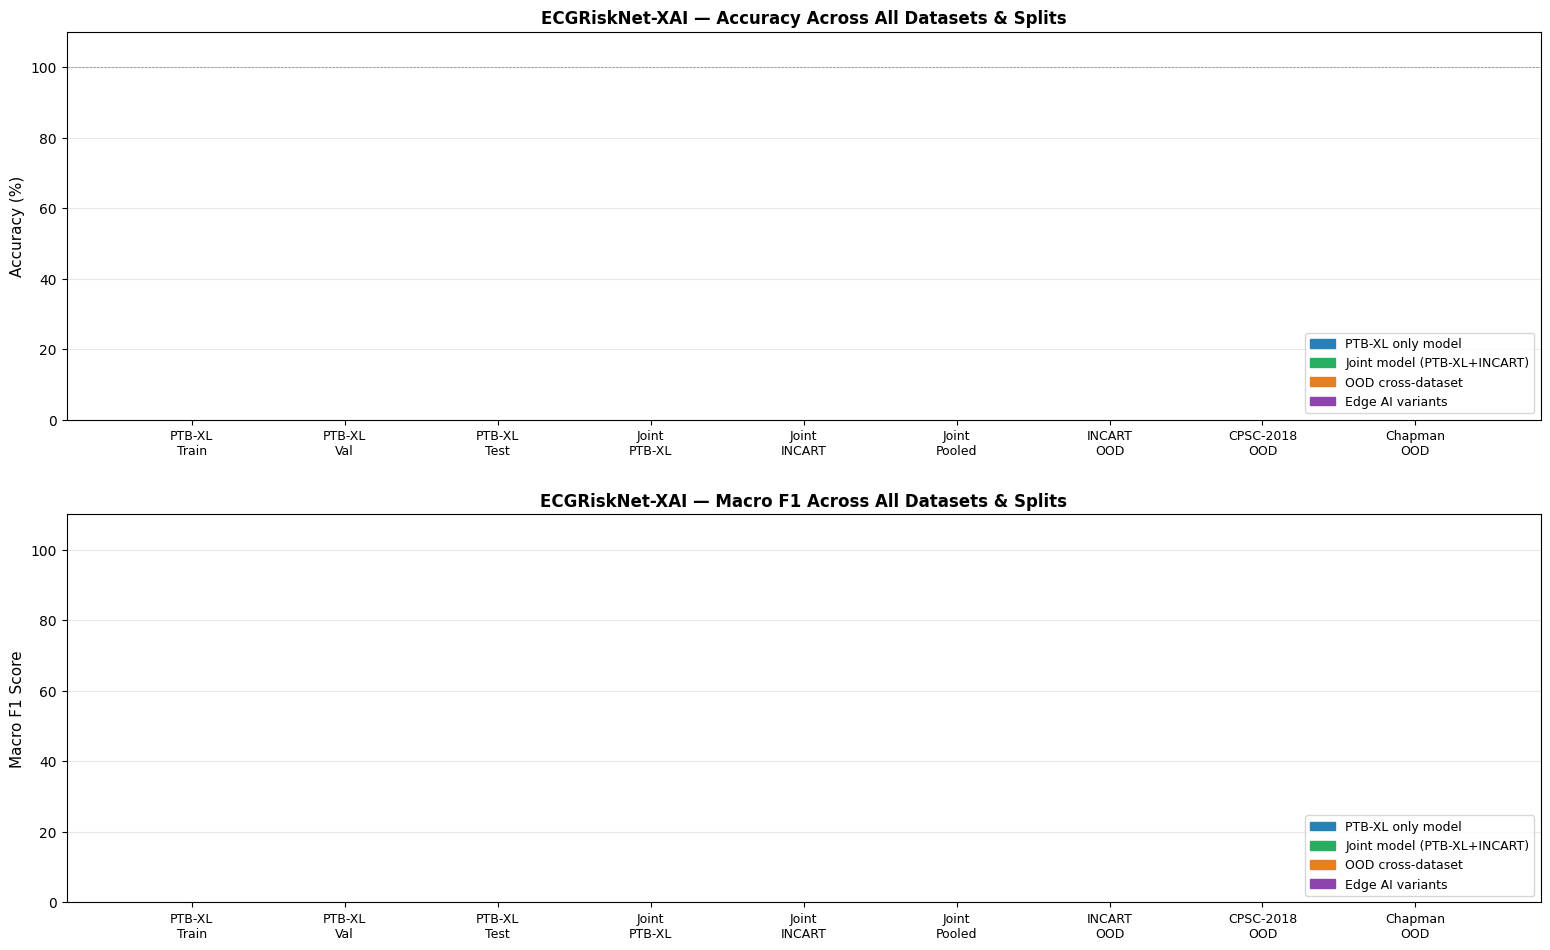

✅ Chart saved → ECG_Project\data\figures\NB10_model_strength_chart.png


In [7]:
# ── Bar chart: Accuracy + Macro F1 for all key splits ──
plot_data = [
    ("PTB-XL\nTrain",  g(ev,"ptbxl_train","accuracy"), g(ev,"ptbxl_train","macro_f1"), "#2980b9"),
    ("PTB-XL\nVal",    g(ev,"ptbxl_val","accuracy"),   g(ev,"ptbxl_val","macro_f1"),   "#2980b9"),
    ("PTB-XL\nTest",   g(tr,"test_accuracy"),          g(tr,"test_macro_f1"),           "#1a5276"),
    ("Joint\nPTB-XL",  g(jr,"ptbxl_val","accuracy"),  g(jr,"ptbxl_val","macro_f1"),    "#27ae60"),
    ("Joint\nINCART",  g(jr,"incart_val","accuracy"),  g(jr,"incart_val","macro_f1"),   "#27ae60"),
    ("Joint\nPooled",  g(jr,"pooled_val","accuracy"),  g(jr,"pooled_val","macro_f1"),   "#1e8449"),
    ("INCART\nOOD",    g(cr,"incart_accuracy"),        g(cr,"incart_macro_f1"),         "#e67e22"),
    ("CPSC-2018\nOOD", g(cr,"cpsc2018_accuracy"),      g(cr,"cpsc2018_macro_f1"),       "#e74c3c"),
    ("Chapman\nOOD",   g(cr,"chapman_accuracy"),       g(cr,"chapman_macro_f1"),        "#922b21"),
]

# Edge AI
if em:
    for v in ["Original","Quantized","Pruned","TorchScript"]:
        acc = g(em, v, "accuracy"); f1 = g(em, v, "macro_f1")
        if acc: plot_data.append((f"Edge\n{v[:5]}", acc, f1, "#8e44ad"))

labels = [d[0] for d in plot_data]
accs   = [d[1]*100 if d[1] else 0 for d in plot_data]
f1s    = [d[2]*100 if d[2] else 0 for d in plot_data]
colors = [d[3] for d in plot_data]

x = np.arange(len(labels))
w = 0.38

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Top: Accuracy ──
bars = axes[0].bar(x, accs, width=w*2, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, accs):
    if val:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("Accuracy (%)", fontsize=11); axes[0].set_ylim(0, 110)
axes[0].set_title("ECGRiskNet-XAI — Accuracy Across All Datasets & Splits", fontweight="bold", fontsize=12)
axes[0].grid(axis="y", alpha=0.3); axes[0].axhline(100, color="gray", lw=0.5, ls="--")

# Legend patches
patches = [
    mpatches.Patch(color="#2980b9", label="PTB-XL only model"),
    mpatches.Patch(color="#27ae60", label="Joint model (PTB-XL+INCART)"),
    mpatches.Patch(color="#e67e22", label="OOD cross-dataset"),
    mpatches.Patch(color="#8e44ad", label="Edge AI variants"),
]
axes[0].legend(handles=patches, fontsize=9, loc="lower right")

# ── Bottom: Macro F1 ──
bars2 = axes[1].bar(x, f1s, width=w*2, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars2, f1s):
    if val:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f"{val/100:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel("Macro F1 Score", fontsize=11); axes[1].set_ylim(0, 110)
axes[1].set_title("ECGRiskNet-XAI — Macro F1 Across All Datasets & Splits", fontweight="bold", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(handles=patches, fontsize=9, loc="lower right")

plt.tight_layout(pad=2.5)
out = FIGS_DIR / "NB10_model_strength_chart.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Chart saved → {out}")


In [8]:
# Training curves from NB4 history (if saved in training_results.json)
history = g(tr, "history") or {}

if history and "train_loss" in history:
    epochs = list(range(1, len(history["train_loss"]) + 1))
    best_ep = g(tr, "best_epoch")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    def plot_pair(ax, t_key, v_key, title, ylabel):
        t = history.get(t_key, [])
        v = history.get(v_key, [])
        if t: ax.plot(epochs[:len(t)], t, label="Train", color="steelblue", lw=1.8)
        if v: ax.plot(epochs[:len(v)], v, label="Val",   color="orange",    lw=1.8)
        if best_ep and (t or v):
            ax.axvline(best_ep, color="red", ls="--", lw=1.2, label=f"Best ep {best_ep}")
        ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plot_pair(axes[0], "train_loss", "val_loss", "CB-Focal + SupCon Loss", "Loss")
    plot_pair(axes[1], "train_acc",  "val_acc",  "Accuracy",               "Accuracy")
    plot_pair(axes[2], "train_f1",   "val_f1",   "Macro F1",               "Macro F1")

    plt.suptitle("PTB-XL Training History (NB4)", fontweight="bold", fontsize=13, y=1.02)
    plt.tight_layout()
    out2 = FIGS_DIR / "NB10_training_history.png"
    plt.savefig(out2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Training curves saved → {out2}")
else:
    print("ℹ️  Training history not embedded in training_results.json.")
    print("   To enable: add 'history': history_dict to training_results in NB4.")


ℹ️  Training history not embedded in training_results.json.
   To enable: add 'history': history_dict to training_results in NB4.


In [9]:
print()
print("╔══════════════════════════════════════════════════════════════════════════════════╗")
print("║   FINAL ONE-SCREEN SUMMARY — ECGRiskNet-XAI                                   ║")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")
print()

def line(label, acc, f1, roc=None, extra=""):
    roc_s = f"  ROC={f4(roc)}" if roc else ""
    print(f"  {'✦' if '★' in label else '·'} {label:<38}  Acc={pct(acc)}  MacroF1={f4(f1)}{roc_s}{extra}")

print("  ── In-Domain (PTB-XL) ──────────────────────────────────────────────")
line("PTB-XL Train (NB6b) ★",    g(ev,"ptbxl_train","accuracy"), g(ev,"ptbxl_train","macro_f1"))
line("PTB-XL Val   (NB6b) ★",    g(ev,"ptbxl_val","accuracy"),   g(ev,"ptbxl_val","macro_f1"))
line("PTB-XL Test  (NB4)  ★",    g(tr,"test_accuracy"),          g(tr,"test_macro_f1"),    g(tr,"test_roc_auc"))

print()
print("  ── Joint Model (PTB-XL + INCART, NB6c) ─────────────────────────────")
line("PTB-XL Val  ★",             g(jr,"ptbxl_val","accuracy"),  g(jr,"ptbxl_val","macro_f1"),  g(jr,"ptbxl_val","roc_auc"))
line("INCART  Val ★",             g(jr,"incart_val","accuracy"), g(jr,"incart_val","macro_f1"), g(jr,"incart_val","roc_auc"))
line("Pooled  Val ★",             g(jr,"pooled_val","accuracy"), g(jr,"pooled_val","macro_f1"), g(jr,"pooled_val","roc_auc"))

print()
print("  ── Cross-Dataset / OOD (never seen in training) ─────────────────────")
line("INCART    (NB6)  ★",        g(cr,"incart_accuracy"),   g(cr,"incart_macro_f1"),   g(cr,"incart_roc_auc"))
line("CPSC-2018 (NB6d) ★",       g(cr,"cpsc2018_accuracy"), g(cr,"cpsc2018_macro_f1"), g(cr,"cpsc2018_roc_auc"))
line("Chapman   (NB6d) ★",       g(cr,"chapman_accuracy"),  g(cr,"chapman_macro_f1"),  g(cr,"chapman_roc_auc"))

print()
if em:
    print("  ── Edge AI Compression (NB7) ────────────────────────────────────────")
    base = g(em,"Original","accuracy") or 0
    for v in ["Original","Quantized","Pruned","TorchScript"]:
        acc = g(em, v, "accuracy"); f1 = g(em, v, "macro_f1")
        lat = g(em, v, "latency_ms"); sz = g(em, v, "size_mb")
        drop = f"  (drop {(base-acc)*100:.2f}pp)" if acc and v != "Original" else ""
        lat_s = f"  {lat:.1f}ms" if lat else ""
        sz_s  = f"  {sz:.1f}MB" if sz else ""
        line(f"{v:<14}", acc, f1, extra=f"{drop}{lat_s}{sz_s}")

print()
print("  ✅ NOTEBOOK 10 COMPLETE")
print("  Saved: NB10_model_strength_chart.png")
print("╚══════════════════════════════════════════════════════════════════════════════════╝")



╔══════════════════════════════════════════════════════════════════════════════════╗
║   FINAL ONE-SCREEN SUMMARY — ECGRiskNet-XAI                                   ║
╚══════════════════════════════════════════════════════════════════════════════════╝

  ── In-Domain (PTB-XL) ──────────────────────────────────────────────
  ✦ PTB-XL Train (NB6b) ★                   Acc=—  MacroF1=—
  ✦ PTB-XL Val   (NB6b) ★                   Acc=—  MacroF1=—
  ✦ PTB-XL Test  (NB4)  ★                   Acc=—  MacroF1=—

  ── Joint Model (PTB-XL + INCART, NB6c) ─────────────────────────────
  ✦ PTB-XL Val  ★                           Acc=—  MacroF1=—
  ✦ INCART  Val ★                           Acc=—  MacroF1=—
  ✦ Pooled  Val ★                           Acc=—  MacroF1=—

  ── Cross-Dataset / OOD (never seen in training) ─────────────────────
  ✦ INCART    (NB6)  ★                      Acc=—  MacroF1=—
  ✦ CPSC-2018 (NB6d) ★                      Acc=—  MacroF1=—
  ✦ Chapman   (NB6d) ★                    